# ⚠ BROKEN — DO NOT RUN (checked 2026-08-16)

Calls `detect_cycles(..., kurt_win_sec=...)`, an argument that does not exist.

Superseded by `airflow_qc_show.ipynb`, which is on the current cycle-rejection scheme.
Either port the cells you need there and delete this file, or repair it against
`Airflow/_scratch/cycle_rejection_spec.md` §1 before running anything.


# What actually goes into the GLM — 5 subjects, Evening vs Morning

For each subject and session, two aligned panels on the same time axis:

- **top** — the 25 Hz cached `signal_raw`, i.e. PsPM's `resp`: native-rate 70 Hz
  anti-alias lowpass only, no highpass, DC kept. This is the trace every cycle
  feature (`RP`/`RA`/`RFR`/`std`/`kurt`) is measured on, and the only thing in
  this notebook that is not derived.
- **bottom** — the per-subject z-scored metric series (`GLM_ZSCORE_METRIC`),
  which is literally the `y` the pooled-session GLM is fitted against.

Everything comes from the QC + GLM code on disk (`airflow_qc.classify_cycles`,
`airflow_glm.build_continuous_series`, `airflow_glm.zscore_subject_series`,
`airflow_glm.admit_trials`) — no re-implementation, so a divergence here is a
divergence in the pipeline, not in the figure.

## Setup

In [1]:
import os, sys, pickle, hashlib, json as _json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from scipy import stats as _stats
from IPython import get_ipython

sys.path.insert(0, '/Users/yotameviatar/startle-1')

import importlib
from Airflow import airflow_config as config
from Airflow import airflow_glm as glm
from Airflow import airflow_qc

# Re-read the .py files on every run of this cell. Without this the kernel keeps
# the module objects it first imported, so edits to airflow_glm.py (new helpers,
# changed gates) are invisible until a full kernel restart -- which silently
# leaves the notebook scoring with older code than what's on disk.
for _m in (config, airflow_qc, glm):
    importlib.reload(_m)

get_ipython().run_line_magic('matplotlib', 'inline')
plt.rcParams.update({'figure.dpi': 110})
print('Setup complete —', matplotlib.get_backend())

Setup complete — inline


## Cache & scoring

Same fingerprinted scoring cache `airflow_qc_show.ipynb` uses — a config edit, a
cache rebuild, or an edit to any of the three pipeline `.py` files moves the
fingerprint and forces a rescore.

In [2]:
METRIC  = 'RA'
FORCE_RESCORE = globals().get('FORCE_RESCORE', False)

cache_path = os.path.join(config.OUTPUT_DIR, "_cache", "airflow_cache.pkl")
with open(cache_path, "rb") as f:
    sessions_cache = pickle.load(f)["sessions"]

def _config_fingerprint():
    items = {}
    for k in dir(config):
        if k.startswith("_"):
            continue
        v = getattr(config, k)
        if callable(v):
            continue
        try:
            _json.dumps(v)
            items[k] = v
        except TypeError:
            pass
    items["__cache_mtime"] = os.path.getmtime(cache_path)
    # Config values alone don't identify the pipeline: editing airflow_glm.py
    # (a gate's logic, a new stage) changes the scores without changing any
    # config value, so the cached scoring would be silently reused.
    items["__code_mtime"] = [os.path.getmtime(_m.__file__)
                             for _m in (config, glm, airflow_qc)]
    blob = _json.dumps(items, sort_keys=True, default=str)
    return hashlib.md5(blob.encode()).hexdigest()[:12]

_score_cache = os.path.join(config.OUTPUT_DIR, "_cache",
                            f"glm_scoring_{_config_fingerprint()}.pkl")

if os.path.exists(_score_cache) and not FORCE_RESCORE:
    with open(_score_cache, "rb") as f:
        _sc = pickle.load(f)
    trials_data, traces = _sc["trials_data"], _sc["traces"]
    print(f"Loaded cached scoring: {os.path.basename(_score_cache)}")
else:
    print("Scoring all sessions (first time only, then cached) ...")
    trials_data, traces = glm.run_glm_scoring(sessions_cache, config)
    with open(_score_cache, "wb") as f:
        pickle.dump({"trials_data": trials_data, "traces": traces}, f)
    print(f"Scored and cached: {os.path.basename(_score_cache)}")

print(f"{len(trials_data)} subjects scored")


Loaded cached scoring: glm_scoring_74a0d53e5c41.pkl
21 subjects scored


## Pass A reproduction (identical to `airflow_qc_show.ipynb`)

In [3]:
def compute_session_qc(subj, sess_key):
    """Mirrors run_glm_scoring's Pass A exactly. Any divergence here shows up as
    notebook scores that disagree with trials_data."""
    sess = sessions_cache[subj][sess_key]
    signal_raw = sess["signal_raw"]
    native_sfreq = float(sess["sfreq"])
    trials_meta = sess["trials_meta"]

    # Despike is applied to the DETECTION copy only, inside phase1. signal_raw
    # stays untouched and is what RA/RFR/std/kurt are measured on (pspm_resp_pp.m
    # `resp` vs `newresp`).
    raw_z, sfreq = glm.phase1_filter_downsample(
        signal_raw, native_sfreq, target_sfreq=config.GLM_TARGET_SFREQ,
        bp_low=config.GLM_CYCLE_BANDPASS[0], bp_high=config.GLM_CYCLE_BANDPASS[1],
        zscore=config.GLM_ZSCORE_RAW, despike=True,
        despike_k=config.GLM_DESPIKE_K, despike_max_run_sec=config.GLM_DESPIKE_MAX_RUN_SEC)

    cycles = glm.detect_cycles(
        raw_z, sfreq, signal_raw, native_sfreq,
        median_win_sec=config.GLM_MEDIAN_WIN_SEC, refractory_sec=config.GLM_REFRACTORY_SEC,
        kurt_win_sec=getattr(config, "CYCLE_KURT_WIN_SEC", 3.0),
        lostlock_prominence=getattr(config, "CYCLE_LOSTLOCK_PROMINENCE", 0.5))

    # The ONE rejection decision, per breath (airflow_qc.classify_cycles).
    cyc_rejected, cyc_reason, cyc_gates, cyc_report = airflow_qc.classify_cycles(cycles, config)
    valid, valid_reason = glm.cycle_validity_to_mask(
        cycles, cyc_rejected, cyc_reason, len(raw_z), sfreq)
    missing_spans = glm._invalid_mask_to_spans(~valid, sfreq)
    knot_cycles = [c for c, bad in zip(cycles, cyc_rejected) if not bad]

    # A trial dropped from the pooled design must also leave `y` -- same rule
    # run_glm_scoring Pass A applies, and the reason this function mirrors it.
    rejected_spans = []
    if getattr(config, "GLM_ESTIMATION", "per_trial") == "pooled_session":
        rejected_spans = glm.rejected_trial_spans(
            trials_meta, cycles, cyc_rejected, config)
        missing_spans = missing_spans + rejected_spans

    n_samples = len(raw_z)
    d105_times = [m["d105_time"] for m in trials_meta if m.get("d105_time") is not None]
    code_times = [m["code_time"] for m in trials_meta if m.get("code_time") is not None]
    win_start = win_end = None
    if d105_times and code_times:
        win_start = min(d105_times) - config.GLM_PRE_FIXATION_SEC
        win_end   = max(code_times) + config.GLM_POST_CODE_SEC
        n_samples = min(n_samples, int(np.ceil(max(win_end, 0.0) * sfreq)))
        if win_start > 0:
            missing_spans = missing_spans + [(0.0, win_start)]

    series, times_full = glm.build_continuous_series(
        knot_cycles, n_samples, sfreq, hp=config.GLM_FINAL_HP, lp=config.GLM_FINAL_LP,
        missing_spans=missing_spans)

    return dict(
        signal_raw=signal_raw, signal_clean=signal_raw, native_sfreq=native_sfreq,
        raw_z=raw_z, sfreq=sfreq, cycles=cycles, series=series, times_full=times_full,
        cyc_rejected=cyc_rejected, cyc_reason=cyc_reason, cyc_gates=cyc_gates,
        cyc_report=cyc_report, valid=valid, valid_reason=valid_reason,
        rejected_spans=rejected_spans,
        win_start=win_start, win_end=win_end)

In [4]:
# Memo of compute_session_qc results. Discarded whenever the fingerprint moves
# (config edit, cache rebuild, or a pipeline .py edit) -- otherwise it would keep
# serving cycles/series computed by code that no longer exists.
_qc_fp = _config_fingerprint()
if globals().get("_qc_memo_fp") != _qc_fp:
    _qc_memo, _qc_memo_fp = {}, _qc_fp
else:
    _qc_memo = globals().get("_qc_memo", {})

def compute_session_qc_memo(subj, sess_key):
    key = (subj, sess_key)
    if key not in _qc_memo:
        _qc_memo[key] = compute_session_qc(subj, sess_key)
    return _qc_memo[key]

def get_subject_zscored_series(subj):
    # Per-subject z-scoring of RA/RFR (config.GLM_ZSCORE_METRIC), pooled across
    # this subject's sessions -- the same transform run_glm_scoring applies.
    # No amplitude ceiling: rejection happens at the cycle level, BEFORE this
    # normalization, so there is nothing left to clip afterwards.
    # Recomputed fresh each call -- cheap (array arithmetic only).
    sess_dict = trials_data.get(subj, {})
    present = [sk for sk in sess_dict if sess_dict[sk]]
    raw = {sk: compute_session_qc_memo(subj, sk) for sk in present}
    zseries = glm.zscore_subject_series({sk: S["series"] for sk, S in raw.items()}, config)
    out = {}
    for sk in present:
        S = raw[sk]
        # Trial admission on the SAME cycles the fit will use
        # (glm.admit_trials) -- run_glm_scoring does this too, so skipping it
        # would leave this notebook disagreeing with trials_data.
        trials_b = [dict(t) for t in sess_dict.get(sk, [])]
        glm.admit_trials(trials_b, S["cycles"], S["cyc_rejected"], config)
        out[sk] = {"series": zseries[sk], "sfreq": S["sfreq"],
                   "valid": S["valid"], "valid_reason": np.array(S["valid_reason"], dtype=object),
                   "trials_b": trials_b}
    return out

## Subject selection

Default: the first 5 subjects (alphabetical) that have **both** sessions scored.
Set `SUBJECTS` by hand to look at specific ones — `SUBJECTS = ['MS18', 'OM16', ...]`.

In [5]:
METRIC   = 'RA'
N_SHOW   = 5
SUBJECTS = globals().get('SUBJECTS', None)

_both = [s for s in sorted(trials_data)
         if all(trials_data[s].get(k) for k in ('eve', 'mor'))]
if SUBJECTS is None:
    SUBJECTS = _both[:N_SHOW]

_missing = [s for s in SUBJECTS if s not in _both]
if _missing:
    raise ValueError(f"no eve+mor pair scored for: {_missing}. Available: {_both}")

print(f"{len(_both)} subjects with both sessions; showing {SUBJECTS}")
print(f"metric {METRIC} | z-scored: {config.GLM_ZSCORE_METRIC.get(METRIC, False)}"
      f" | series {config.GLM_TARGET_SFREQ:g} Hz | raw {config.CACHE_SFREQ:g} Hz")

17 subjects with both sessions; showing ['AB22', 'AG05', 'AH19', 'AK12', 'AS09']
metric RA | z-scored: True | series 10 Hz | raw 25 Hz


## Figures

One figure per subject, Evening left / Morning right, time axis shared down each
column so a shaded rejection in the raw panel lines up with the gap it produces
in `y`.

Shading, in the order the gates are attributed (`airflow_qc.GATE_ORDER`):

- coloured spans — **rejected breath cycles**, one colour per gate
- grey hatched spans — **blanked trial windows**: a trial that fails
  `admit_trials` is dropped from the event train *and* its
  `[onset, onset+TRIAL_WINDOW_SEC)` is set to NaN in `y` (`pooled_session` only)
- dashed vlines — admitted trial onsets (`code_time`); rejected onsets in red

The series panel is plotted with NaNs left in, so every blank is a real hole in
the regression's data, not a line drawn through it.

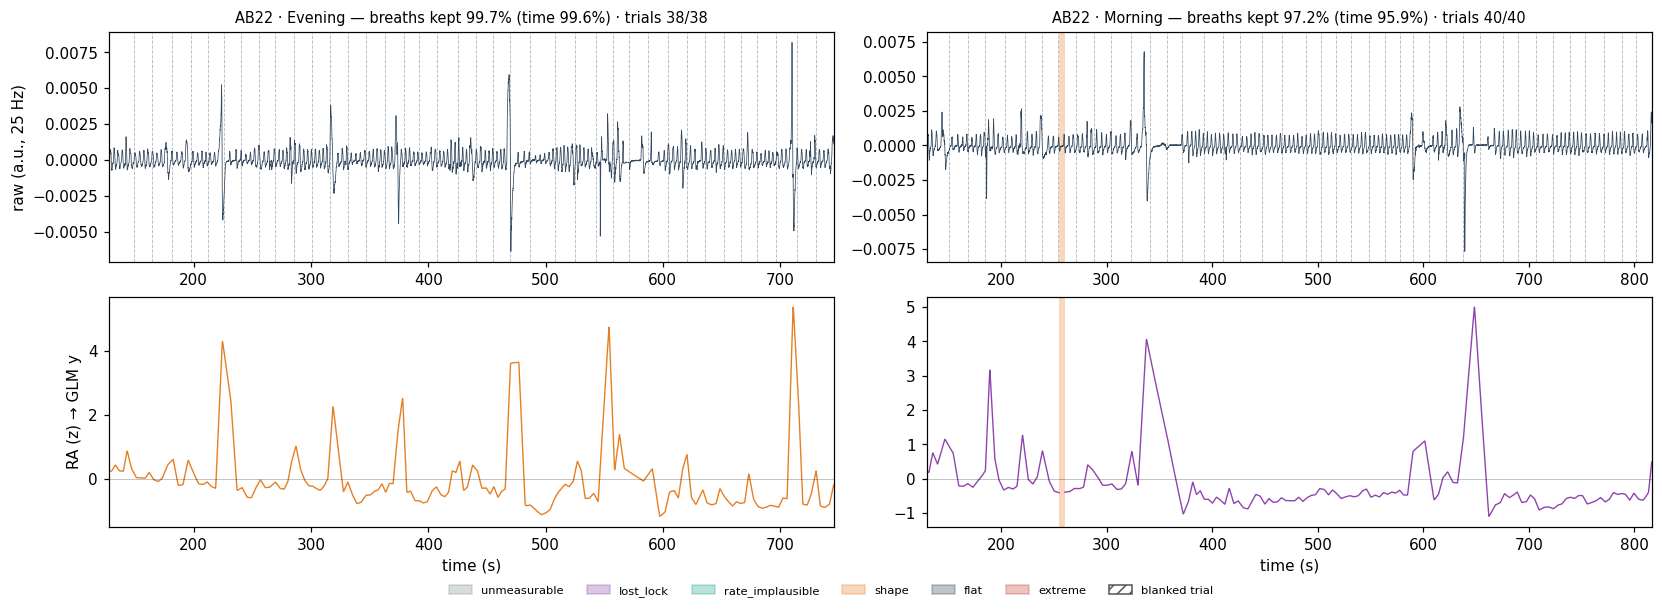

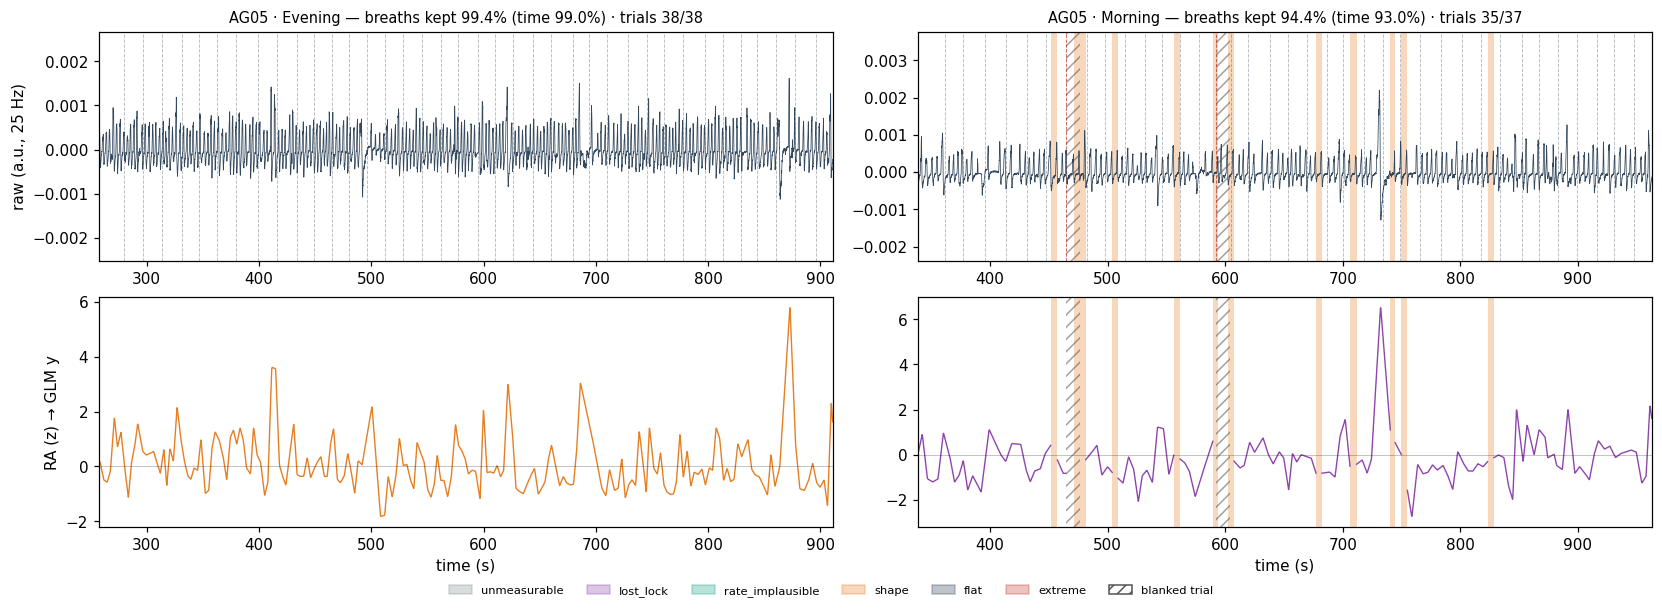

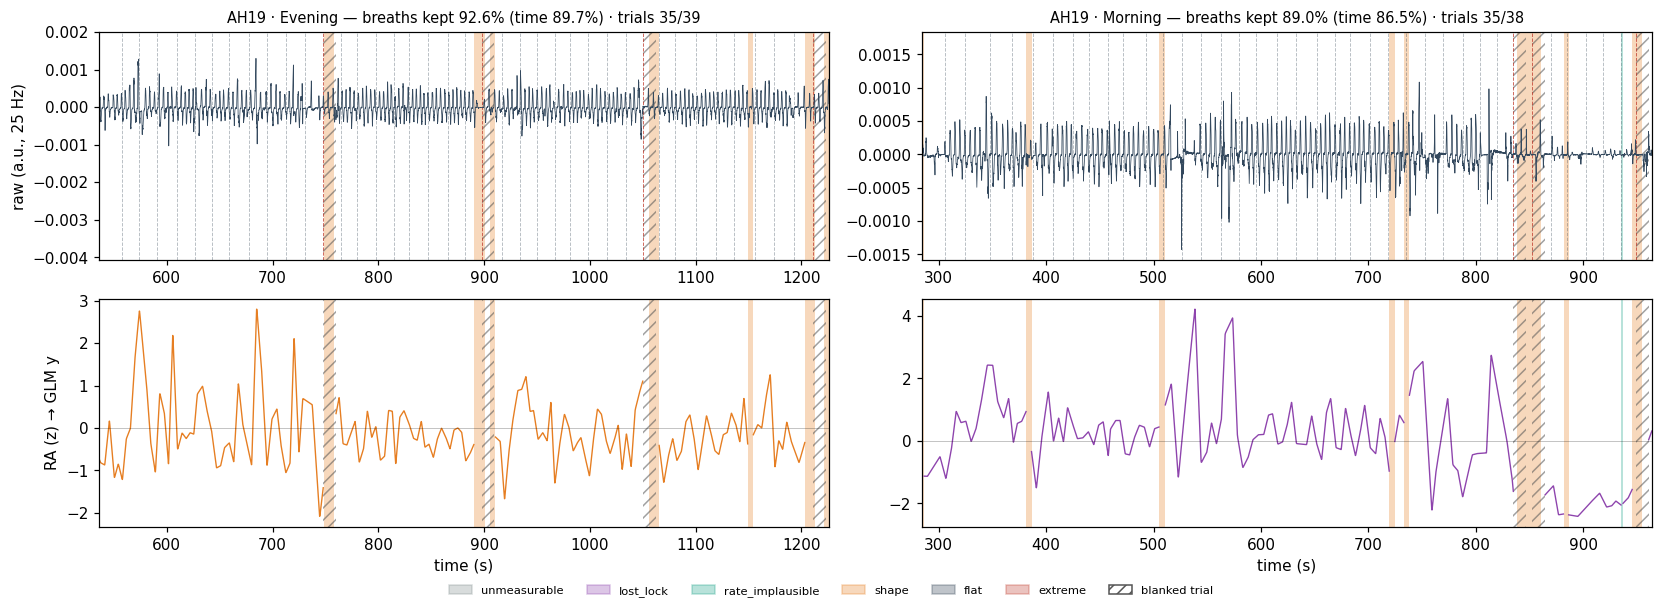

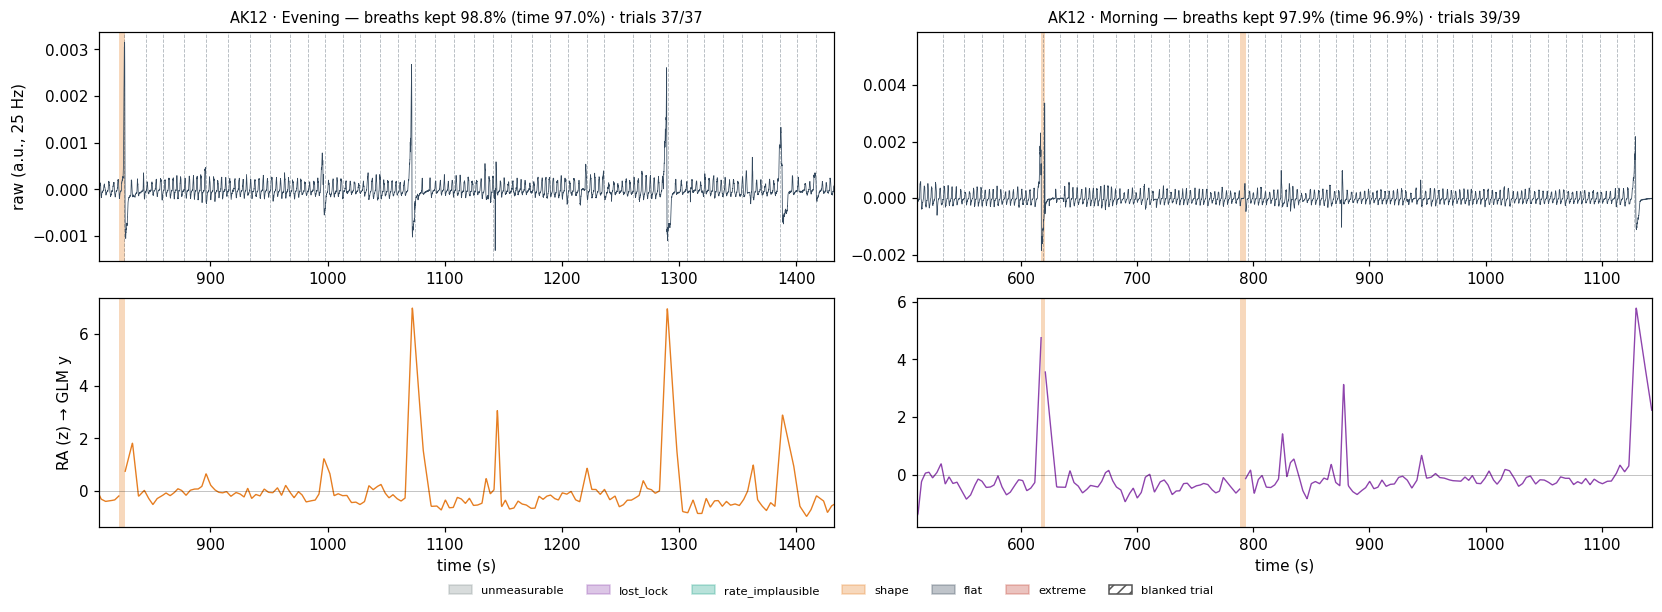

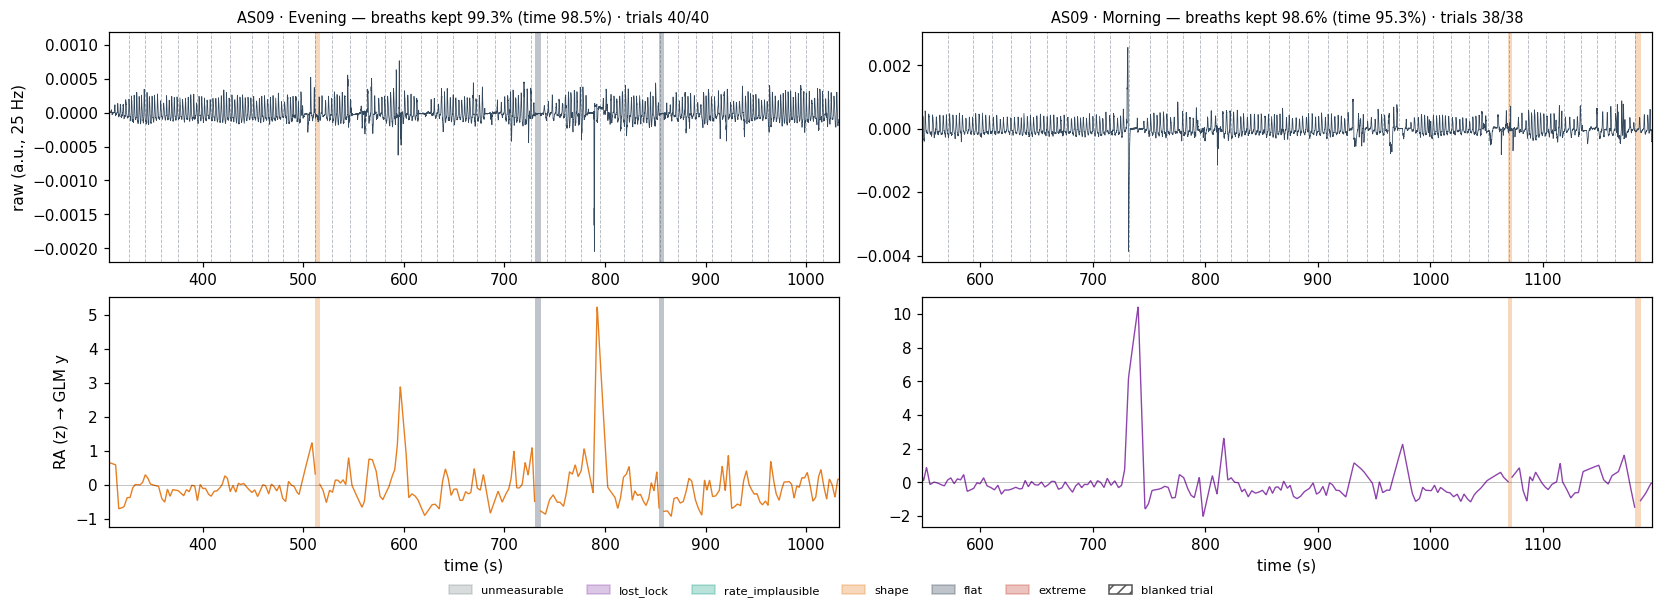

In [6]:
GATE_COLORS = {
    'unmeasurable':     '#7F8C8D',
    'lost_lock':        '#8E44AD',
    'rate_implausible': '#16A085',
    'shape':            '#E67E22',
    'flat':             '#2C3E50',
    'extreme':          '#C0392B',
}

def _cycle_spans_by_gate(S):
    spans = {g: [] for g in airflow_qc.GATE_ORDER}
    for c, bad, why in zip(S['cycles'], S['cyc_rejected'], S['cyc_reason']):
        if bad:
            spans[why].append((c['onset_time'], c['onset_time'] + c['RP']))
    return spans


def plot_subject(subj, metric=None, figsize=(15, 5.2)):
    metric = metric or METRIC
    zdata = get_subject_zscored_series(subj)
    sess_keys = [k for k in ('eve', 'mor') if k in zdata]

    fig, axes = plt.subplots(2, len(sess_keys), figsize=figsize,
                             squeeze=False, constrained_layout=True)

    for col, sk in enumerate(sess_keys):
        S = compute_session_qc_memo(subj, sk)
        Z = zdata[sk]
        ax_raw, ax_ser = axes[0, col], axes[1, col]

        # --- raw 25 Hz, exactly as cached (no filtering, DC kept) ---
        t_raw = np.arange(len(S['signal_raw'])) / S['native_sfreq']
        ax_raw.plot(t_raw, S['signal_raw'], lw=0.5, color='#34495E')

        # --- the z-scored metric series = the GLM's y ---
        t_ser = np.arange(len(Z['series'][metric])) / Z['sfreq']
        ax_ser.plot(t_ser, Z['series'][metric], lw=0.9,
                    color=config.EVE_COLOR if sk == 'eve' else config.MOR_COLOR)
        ax_ser.axhline(0, lw=0.5, color='k', alpha=0.3)

        # --- rejected breath cycles ---
        spans = _cycle_spans_by_gate(S)
        for g in airflow_qc.GATE_ORDER:
            for a, b in spans[g]:
                for ax in (ax_raw, ax_ser):
                    ax.axvspan(a, b, color=GATE_COLORS[g], alpha=0.30, lw=0, zorder=0)

        # --- blanked trial windows (pooled_session only) ---
        for a, b in S['rejected_spans']:
            for ax in (ax_raw, ax_ser):
                ax.axvspan(a, b, facecolor='none', edgecolor='#555555',
                           hatch='///', lw=0.0, alpha=0.55, zorder=0)

        # --- trial onsets ---
        n_adm = 0
        for t in Z['trials_b']:
            rej = t['rejected']
            n_adm += (not rej)
            ax_raw.axvline(t['onset_time'], lw=0.6, ls='--',
                           color='#C0392B' if rej else '#2C3E50',
                           alpha=0.8 if rej else 0.35, zorder=1)

        if S['win_start'] is not None:
            for ax in (ax_raw, ax_ser):
                ax.set_xlim(S['win_start'], S['win_end'])

        rep = S['cyc_report']
        n_tr = len(Z['trials_b'])
        ax_raw.set_title(
            f"{subj} · {config.SESSION_MAP[sk]['label']} — "
            f"breaths kept {rep['kept_frac']:.1%} "
            f"(time {rep['kept_seconds_frac']:.1%}) · "
            f"trials {n_adm}/{n_tr}",
            fontsize=9.5)
        ax_raw.set_ylabel('raw (a.u., 25 Hz)' if col == 0 else '')
        zlab = ' (z)' if config.GLM_ZSCORE_METRIC.get(metric, False) else ''
        ax_ser.set_ylabel(f'{metric}{zlab} → GLM y' if col == 0 else '')
        ax_ser.set_xlabel('time (s)')
        if rep['abstained']:
            ax_ser.text(0.01, 0.03, 'abstained: ' + ','.join(rep['abstained']),
                        transform=ax_ser.transAxes, fontsize=7, color='#C0392B')

    handles = [mpatches.Patch(color=GATE_COLORS[g], alpha=0.30, label=g)
               for g in airflow_qc.GATE_ORDER]
    handles.append(mpatches.Patch(facecolor='white', edgecolor='#555555',
                                  hatch='///', label='blanked trial'))
    fig.legend(handles=handles, loc='lower center', ncol=7, fontsize=7.5,
               frameon=False, bbox_to_anchor=(0.5, -0.05))
    return fig


for _s in SUBJECTS:
    plot_subject(_s)
    plt.show()

## What each session contributes to the contrast

The per-session numbers behind the figures: how much of the recording survived
the cycle gates, how many trials were admitted, and the β the pooled-session
GLM actually returns for that `y`.

In [7]:
import pandas as pd

_rows = []
for subj in SUBJECTS:
    zdata = get_subject_zscored_series(subj)
    for sk in ('eve', 'mor'):
        if sk not in zdata:
            continue
        S, Z = compute_session_qc_memo(subj, sk), zdata[sk]
        rep = S['cyc_report']
        # Restricted to the analysis window: everything before win_start is
        # blanked by construction (pre-fixation lead-in), so a whole-array NaN
        # fraction would mostly report recording length, not data loss.
        y = Z['series'][METRIC]
        i0 = int(max(S['win_start'], 0.0) * Z['sfreq']) if S['win_start'] is not None else 0
        i1 = min(int(np.ceil(S['win_end'] * Z['sfreq'])), len(y)) if S['win_end'] is not None else len(y)
        y = y[i0:i1]
        adm = [t for t in Z['trials_b'] if not t['rejected']]
        vals = [t.get(f'score_{METRIC.lower()}') for t in trials_data[subj][sk]
                if not t.get('rejected') and t.get(f'score_{METRIC.lower()}') is not None]
        vals = [v for v in vals if np.isfinite(v)]
        _rows.append({
            'Subject': subj,
            'Session': config.SESSION_MAP[sk]['label'],
            'Cycles': rep['n_cycles'],
            'Kept %': 100 * rep['kept_frac'],
            'Kept % (time)': 100 * rep['kept_seconds_frac'],
            'Trials adm.': f"{len(adm)}/{len(Z['trials_b'])}",
            'y NaN % (in win)': 100 * float(np.mean(~np.isfinite(y))),
            f'mean beta_{METRIC}': np.mean(vals) if vals else np.nan,
        })

_tbl = pd.DataFrame(_rows).set_index(['Subject', 'Session'])
_tbl.round(2)

Cycles  Kept %  Kept % (time) Trials adm.  y NaN % (in win)  \
Subject Session                                                                
AB22    Evening     334   99.70          99.56       38/38              0.02   
        Morning     318   97.17          95.91       40/40              0.79   
AG05    Evening     476   99.37          98.99       38/38              0.02   
        Morning     392   94.39          92.96       35/37             12.13   
AH19    Evening     446   92.60          89.69       35/39             10.98   
        Morning     319   89.03          86.50       35/38             10.95   
AK12    Evening     582   98.80          97.03       37/37              0.86   
        Morning     487   97.95          96.94       39/39              1.36   
AS09    Evening     578   99.31          98.47       40/40              2.02   
        Morning     573   98.60          95.25       38/38              1.32   

                 mean beta_RA  
Subject Session                
AB22    Evening         -0.13  
        Morning          0.10  
AG05    Evening         -0.25  
        Morning         -0.40  
AH19    Evening          0.54  
        Morning          0.37  
AK12    Evening         -0.03  
        Morning         -0.24  
AS09    Evening         -0.23  
        Morning          0.30